In [1]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm
from numba import njit, prange, set_num_threads

In [46]:
def new_mapping(c):
    pass


@njit(parallel=True)
def compute_par(complex_values):
        
    N = 200
    k = 100

    c_const = 0.285 + 0.01j

    iter_lst = np.zeros(len(complex_values))

    for idx in prange(len(complex_values)):

        c = complex_values[idx]
        iter = 0
        while (iter < N) and (np.abs(c) < k):
            c = (c**2) + c_const #(1/np.sin(np.exp(c)) + 0.2) + (c_const/c)
            iter += 1

        iter_lst[idx] = iter
    
    return iter_lst

@njit(parallel=True)
def compute_par_mandel(complex_values):
        
    N = 200
    k = 100


    iter_lst = np.zeros(len(complex_values))

    for idx in prange(len(complex_values)):
    
        c_const = complex_values[idx]

        c = 0#0.285 + 0.01j
        iter = 0
        while (iter < N) and (np.abs(c) < k):
            c = (c**2) + c_const #(1/np.sin(np.exp(c)) + 0.2) + (c_const/c)
            iter += 1

        iter_lst[idx] = iter
    
    return iter_lst

def compute_parallel(lims_x, lims_y, n_pts = 1000):

    real_part = np.linspace(-lims_x, 0.7, n_pts)
    imag_part = np.linspace(-lims_y, lims_y, n_pts)

    X, Y = np.meshgrid(real_part, imag_part)

    complex_lattice = X + 1j*Y
    complex_values = complex_lattice.flatten()

    d_image = compute_par_mandel(complex_values)

    iter_vals = np.array(d_image).reshape(complex_lattice.shape)

    return iter_vals, X, Y

In [ ]:
fractal, X, Y = compute_parallel(1.5, 1.5, 2000)

Text(0.5, 1.0, 'Mandelbrot Set')

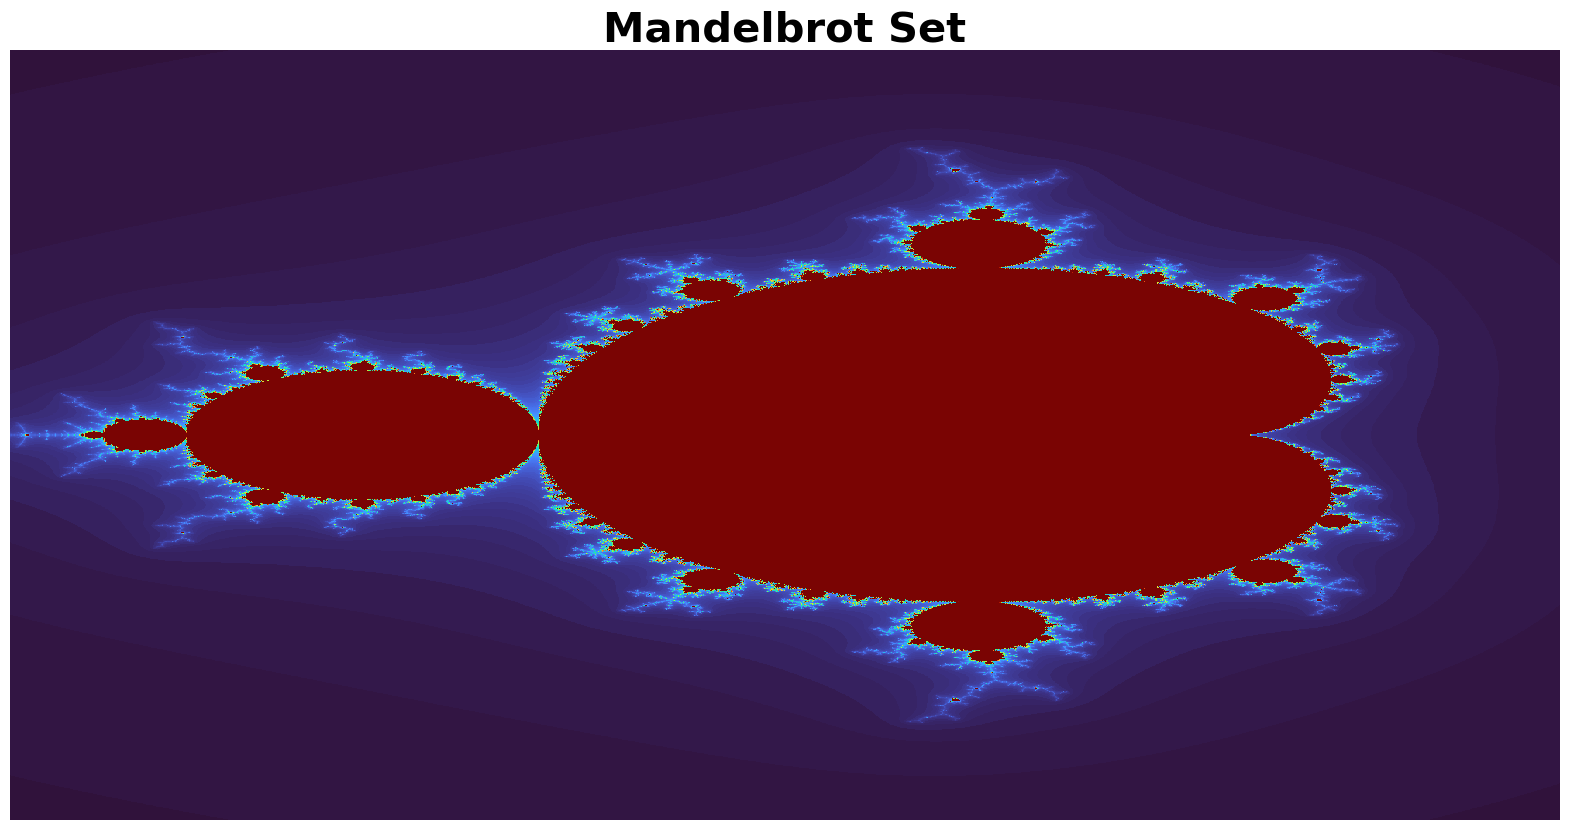

In [53]:
fig, ax = plt.subplots(figsize = (20, 10))
#plt.ylim(-.5, .5)
#plt.xlim(-0.75, 0.75)
plot = ax.pcolormesh(X,
                     Y,
                     fractal/np.max(fractal), cmap = "turbo")
#plt.colorbar(plot)
#plt.title("Logistic Fractal Using Ideas of Julia Fractals", weight = "bold", size = 15)
plt.axis("off")
plt.title("Mandelbrot Set", weight = "bold", size = 30)

In [78]:
lims_x = 2
lims_y = 2

real_part = np.linspace(-lims_x, lims_x, 1000)
imag_part = np.linspace(-lims_y, lims_y, 1000)

X, Y = np.meshgrid(real_part, imag_part)

complex_lattice = X + 1j*Y
complex_values = complex_lattice.flatten()

N = 1000
k = 2

iter_lst = []
pbar = tqdm(total=len(complex_values), leave=True)

for c in complex_values:
    z = 0 + 0j
    iter = 0

    while (iter < N) and (np.abs(z) < k):
        z = np.sin(z) + c#(np.abs(z.real) + 1j * np.abs(z.imag))**2 + c
        iter += 1

    pbar.update(1)
    iter_lst.append(iter)

pbar.close()

100%|██████████| 1000000/1000000 [02:45<00:00, 6037.12it/s] 


In [79]:
iter_vals = np.array(iter_lst).reshape(complex_lattice.shape)

In [80]:
np.unique(iter_vals)

array([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,   11,
         12,   13,   14,   15,   16,   17,   18,   19,   21,   22,   24,
         27, 1000])

(-2.002002002002002, 2.002002002002002, -2.002002002002002, 2.002002002002002)

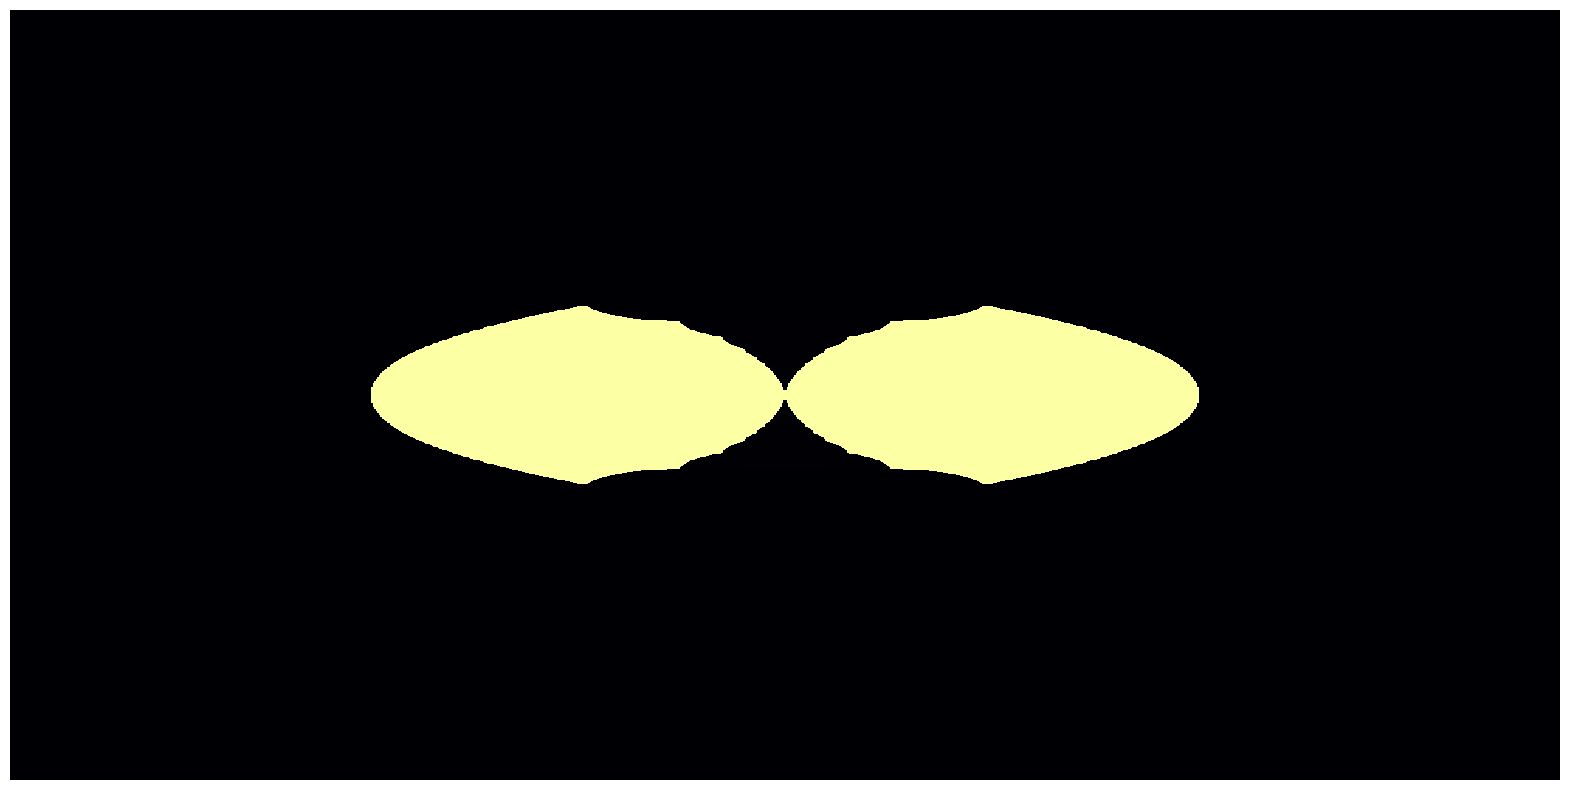

In [82]:
fig, ax = plt.subplots(figsize = (20, 10))
#plt.ylim(-1, 1)
#plt.xlim(-2, 1)
plot = ax.pcolormesh(X,
                     Y,
                     iter_vals, cmap = "inferno")
#plt.colorbar(plot)
#plt.title("Logistic Fractal Using Ideas of Julia Fractals", weight = "bold", size = 15)
plt.axis("off")